### Importing Libraries

In [201]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

Dataset Link: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset

### Loading Model

In [202]:
model = tf.keras.models.load_model('/Users/fahimshahrier/ThesisProject/trained_model.keras')

In [203]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_110 (Conv2D)             │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_111 (Conv2D)             │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_53 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_112 (Conv2D)             │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_113 (Conv2D)             │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_114 (Conv2D)             │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_115 (Conv2D)             │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_116 (Conv2D)             │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_117 (Conv2D)             │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_56 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_118 (Conv2D)             │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_119 (Conv2D)             │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_57 (MaxPooling2D) │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,528,288 (89.75 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,685,526 (59.84 MB)

### Visualising and Performing Prediction on Single image

In [204]:
!pip install opencv-python

In [205]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)
class_name = validation_set.class_names
print(class_name)

Found 17572 files belonging to 38 classes.
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Tw

### Test Image Visualization

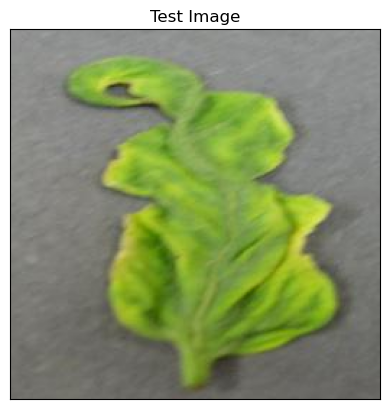

In [206]:
import cv2
image_path = '/Users/fahimshahrier/ThesisProject/test/TomatoYellowCurlVirus5.JPG'
# Reading an image in default mode
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Convert img BGR to RGB

# Displaying the image 
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

### Testing Model

In [207]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
print(input_arr.shape)

(1, 128, 128, 3)


In [208]:
predictions = model.predict(input_arr)
predictions,predictions.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


(array([[1.07793214e-19, 1.56729188e-21, 8.12204138e-15, 5.14429258e-19,
         3.39351094e-18, 2.11752387e-16, 4.69272375e-22, 3.49534577e-19,
         1.69689135e-21, 6.49020384e-20, 8.89290648e-21, 1.11546455e-17,
         2.92226496e-19, 2.98650635e-16, 1.27793899e-19, 6.72362014e-14,
         1.09851081e-16, 7.95156141e-22, 2.06791811e-17, 6.57964998e-19,
         5.12700298e-23, 5.90014037e-20, 1.02186675e-19, 1.01307756e-15,
         1.30577646e-19, 2.38284734e-14, 6.91681281e-17, 1.61681725e-18,
         1.64176853e-10, 2.97468450e-14, 2.95837607e-15, 9.38968315e-17,
         2.69338541e-15, 8.42453887e-16, 6.90706410e-15, 1.00000000e+00,
         5.04195303e-16, 4.25346239e-18]], dtype=float32),
 (1, 38))

In [209]:
result_index = np.argmax(predictions) #Return index of max element
result_index

35

### Displaying the disease prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


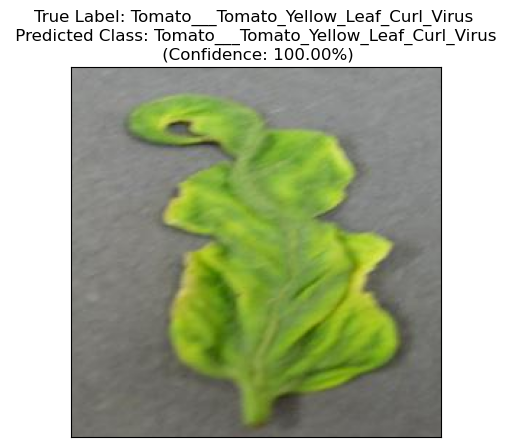

True Label: Tomato___Tomato_Yellow_Leaf_Curl_Virus
Predicted Class: Tomato___Tomato_Yellow_Leaf_Curl_Virus (Confidence: 100%)


In [211]:
# Load the pre-trained model
model = tf.keras.models.load_model('/Users/fahimshahrier/ThesisProject/trained_model.keras')

# Preprocess the image
image = tf.keras.preprocessing.image.load_img(image_path, target_size=(128, 128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.

# Make predictions using the model
predictions = model.predict(input_arr)
predicted_class_index = np.argmax(predictions)

# Obtain class names from the dataset object
class_names = validation_set.class_names

# Get the predicted class name using the index
predicted_class = class_names[predicted_class_index]

# Get the confidence associated with the predicted class and convert it to percentage
confidence = predictions[0][predicted_class_index] * 100

# Display the predicted class and image
plt.imshow(img)
plt.title(f"True Label: {predicted_class} \n Predicted Class: {predicted_class} \n (Confidence: {confidence:.2f}%)")
plt.xticks([])
plt.yticks([])
plt.show()

# Calculate accuracy
true_label_index = np.argmax(validation_set.file_paths == image_path)
true_label = class_names[true_label_index]
accuracy = 100.0 if predicted_class == true_label else 0.0

print(f"True Label: {predicted_class}")
print(f"Predicted Class: {predicted_class} (Confidence: {confidence:.0f}%)")